# **MILESTONE 2**

Nama : Zafirah Aida Adista

Batch : CODA-RMT-015

Program ini dibuat sebagai bagian dari analisis dan visualisasi data untuk memahami faktor-faktor yang memengaruhi profit dan memberikan rekomendasi strategi bisnis berbasis data

## **Global Skincare & Beauty E-Store: E-Commerce Analysis**
Perkembangan industri kecantikan global dalam beberapa tahun terakhir menunjukkan pertumbuhan yang signifikan. Meningkatnya kesadaran masyarakat terhadap perawatan kulit, ditambah dengan kemudahan akses melalui platform e-commerce, mendorong perubahan perilaku konsumen dari pembelian offline ke online.

Namun dengan semakin banyaknya kompetitor dan beragamnya preferensi konsumen di tiap wilayah, diperlukan pemahaman mendalam tentang profitabilitas produk, perilaku konsumen, dan efektivitas strategi diskon agar bisnis dapat membuat keputusan strategis yang tepat.


**Link Dashboard:**

https://public.tableau.com/app/profile/zafirah.adista/viz/Milestone_17724314944580/Dashboard1?publish=yes

## **A. Identifikasi Masalah**


### Analisis SMART Framework
*   **Specific:** Menganalisis performa penjualan skincare global berdasarkan
Kategori dan produk terlaris, negara dengan kontribusi profit terbesar, tren penjualan tahunan, dampak pemberian diskon terhadap profit dan perbedaan performa antar segmen pelanggan

*   **Measurable**: Diukur menggunakan metrik Sales, Profit, Discount, dan Quantity

*   **Achievable**: Analisis dilakukan menggunakan dataset transaksi periode 2020-2023 yang mencakup variabel profit, produk, diskon, kategori, negara, dan segmentasi pelanggan.

*  **Relevant**: Hasil analisis akan digunakan oleh Business Owner/Manajemen untuk mengoptimalkan strategi pricing & diskon, menentukan prioritas kategori produk, memfokuskan distribusi ke negara berpotensi tinggi, meningkatkan profitabilitas bisnis secara global

*   **Time-bound**: Analisis difokuskan pada periode 2020-2023 untuk menghasilkan rekomendasi strategis yang dapat diterapkan pada perencanaan bisnis tahun berikutnya

### Problem Statement

Business owner ingin menganalisis performa penjualan skincare global periode 2020-2023 untuk mengidentifikasi kategori dan produk terlaris, negara dengan kontribusi revenue dan profit terbesar, tren penjualan tahunan, serta dampak pemberian diskon terhadap profit dan perbedaan performa antar segmen pelanggan, menggunakan metrik Sales, Profit, Discount, dan Quantity guna mengoptimalkan strategi pricing & diskon, menentukan prioritas kategori produk, memfokuskan distribusi ke negara berpotensi tinggi, meningkatkan profitabilitas bisnis secara global pada perencanaan bisnis tahun berikutnya.

### Main Problem:

Apa saja fakto-faktor utama yang mempengaruhi  profitabilitas penjualan skincare global selama periode 2020-2023?

Untuk memperjelas fokus analisis, digunakan pendekatan **5W+1H** sebagai kerangka dalam mengidentifikasi dan merumuskan permasalahan sebelum dilakukan analisis data.


**Penjabaran masalah dengan metode 5W+1H:**
1. Kategori dan produk mana yang menghasilkan profit tertinggi?
2. Negara mana yang menghasilkan profit tertinggi?
3. Segmen pelanggan mana yang paling menghasilkan profit tertinggi dan responsif terhadap diskon?
4. Bagaimana tren Profit dari tahun ke tahun (2020-2023)?
5. Berapa Mean, median, Modus dari Quantity pada setiap kategori produk?
6. Apakah terdapat pengaruh yang signifikan antara besaran diskon terhadap Profit yang dihasilkan?

## **B. Data Loading**


Sumber data: https://www.kaggle.com/datasets/shandeep777/e-commerce-analysis-global-skincare-e-store/data

In [ ]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
from scipy.stats import spearmanr

In [ ]:
# Membaca file Excel ke dalam DataFrame
df = pd.read_excel('global skincare.xlsx')

# Menampilkan 5 baris pertama dataset
df.head()

,Row ID,Order ID,Order Date,Customer ID,Segment,City,State,Country,Country latitude,Country longitude,Region,Market,Category,Product,Quantity,Sales,Discount,Profit
0,38153,US-2015-MF18250140-42362,2023-12-24,MF-182501408,Corporate,Little Rock,Arkansas,United States,37.090240,-95.712891,Southern US,USCA,Body care,Acqua di Parma Blu Mediterraneo Arancia di Cap...,5,25,0.00,10.00
1,15423,ES-2014-MS1783048-41915,2022-10-03,MS-1783048,Consumer,Erftstadt,North Rhine-Westphalia,Germany,51.165691,10.451526,Western Europe,Europe,Body care,Acqua di Parma Blu Mediterraneo Arancia di Cap...,3,15,0.00,1.50
2,25126,ID-2014-TB2125059-41973,2022-11-30,TB-2125059,Consumer,Jambi,Jambi,Indonesia,-0.789275,113.921327,Southeastern Asia,Asia Pacific,Body care,Acqua di Parma Blu Mediterraneo Arancia di Cap...,2,10,0.47,0.30
3,24686,IN-2015-MH1811558-42185,2023-06-30,MH-1811558,Self-Employed,Aligarh,Uttar Pradesh,India,20.593684,78.962880,Southern Asia,Asia Pacific,Body care,Acqua di Parma Blu Mediterraneo Arancia di Cap...,4,20,0.00,8.00
4,26401,IN-2012-KL16645144-41242,2020-11-29,KL-16645144,Consumer,Ho Chi Minh City,Ho Chí Minh City,Vietnam,14.058324,108.277199,Southeastern Asia,Asia Pacific,Body care,Acqua di Parma Blu Mediterraneo Arancia di Cap...,1,5,0.17,1.65


In [ ]:
# Menampilkan jumlah baris dan kolom dataset
df.shape

(51041, 18)

In [ ]:
# Mengecek tipe data masing-masing kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51041 entries, 0 to 51040
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             51041 non-null  int64         
 1   Order ID           51041 non-null  object        
 2   Order Date         51041 non-null  datetime64[ns]
 3   Customer ID        51041 non-null  object        
 4   Segment            51041 non-null  object        
 5   City               51041 non-null  object        
 6   State              51041 non-null  object        
 7   Country            51041 non-null  object        
 8   Country latitude   51041 non-null  float64       
 9   Country longitude  51041 non-null  float64       
 10  Region             51041 non-null  object        
 11  Market             51041 non-null  object        
 12  Category           51041 non-null  object        
 13  Product            51041 non-null  object        
 14  Quanti



*   **Jumlah Baris dan Kolom**: Terdapat 51041 baris dan 17 kolom
*   **Tipe Data:** Sudah sesuai dengan fungsinya. Terdapat tipe datetime, int, float, dan object

*   **Missing Value:** Tidak terdapat missing value pada dataset



In [ ]:
# Mengecek nilai unique pada masing-masing kolom
df.nunique().sort_values(ascending=False)

,0
Row ID,51041
Order ID,25659
Customer ID,17383
Profit,5388
City,3647
Product,3539
Order Date,1430
State,1101
Sales,983
Country latitude,164


In [ ]:
# Ringkasan statistik data tipe numerik
df.describe()

,Row ID,Order Date,Country latitude,Country longitude,Quantity,Sales,Discount,Profit
count,51041.000000,51041,51041.000000,51041.000000,51041.000000,51041.000000,51041.000000,51041.000000
mean,25640.878549,2022-05-12 03:35:27.583707392,24.493591,-4.607718,5.415960,126.027703,0.142944,20.615163
min,1.000000,2020-01-01 00:00:00,-40.900557,-106.346771,1.000000,2.000000,0.000000,-1746.000000
25%,12823.000000,2021-06-19 00:00:00,12.879721,-95.712891,2.000000,24.000000,0.000000,0.000000
50%,25639.000000,2022-07-09 00:00:00,35.861660,2.213749,4.000000,56.000000,0.000000,7.200000
75%,38452.000000,2023-05-22 00:00:00,38.963745,43.679291,7.000000,131.000000,0.200000,24.800000
max,51290.000000,2023-12-31 00:00:00,61.924110,174.885971,20.000000,3940.000000,0.850000,1820.000000
std,14804.063257,NaN,24.123517,80.288698,4.910045,234.649497,0.212318,83.019849


## **C. Data Cleaning**


In [ ]:
# Mengecek duplikat values
print(f'\nDuplicates: {df.duplicated().sum()}')


Duplicates: 0


Tidak ada nilai duplikat

In [ ]:
# Standardize columns
df.columns = df.columns.str.strip()

In [ ]:
# Mengecek value kolom Category
df['Category'].value_counts()

,count
Category,
Body care,18219
Make up,12202
Hair care,8366
Home and Accessories,6270
Face care,5876
Body Care,108


Terdapat 2 penulisan untuk 1 nilai yang sama. Dilakukan data cleaning untuk mengatasi hal ini

In [ ]:
# Mengganti penulisan yang berbeda menjadi 1 penulisan
df['Category'] = df['Category'].replace({
    'Body Care': 'Body care'})

In [ ]:
# Membuat kolom baru dari kolom "OrderDate" untuk memudahkan analisis

# Membuat kolom baru berisi tahun transaksi
df['Year'] = df['Order Date'].dt.year

# Membuat kolom bulan transaksi
df['Month'] = df['Order Date'].dt.month

# Membuat kolom periode bulanan
df['YearMonth'] = df['Order Date'].dt.to_period('M')

In [ ]:
# Menghapus kolom "RowID" karena tidak diperlukan dalam analisis
df.drop('Row ID', axis=1, inplace=True)

In [ ]:
# Menampilkan preview dataset setelah dilakukan cleaning
df.head()

,Order ID,Order Date,Customer ID,Segment,City,State,Country,Country latitude,Country longitude,Region,Market,Category,Product,Quantity,Sales,Discount,Profit,Year,Month,YearMonth
0,US-2015-MF18250140-42362,2023-12-24,MF-182501408,Corporate,Little Rock,Arkansas,United States,37.090240,-95.712891,Southern US,USCA,Body care,Acqua di Parma Blu Mediterraneo Arancia di Cap...,5,25,0.00,10.00,2023,12,2023-12
1,ES-2014-MS1783048-41915,2022-10-03,MS-1783048,Consumer,Erftstadt,North Rhine-Westphalia,Germany,51.165691,10.451526,Western Europe,Europe,Body care,Acqua di Parma Blu Mediterraneo Arancia di Cap...,3,15,0.00,1.50,2022,10,2022-10
2,ID-2014-TB2125059-41973,2022-11-30,TB-2125059,Consumer,Jambi,Jambi,Indonesia,-0.789275,113.921327,Southeastern Asia,Asia Pacific,Body care,Acqua di Parma Blu Mediterraneo Arancia di Cap...,2,10,0.47,0.30,2022,11,2022-11
3,IN-2015-MH1811558-42185,2023-06-30,MH-1811558,Self-Employed,Aligarh,Uttar Pradesh,India,20.593684,78.962880,Southern Asia,Asia Pacific,Body care,Acqua di Parma Blu Mediterraneo Arancia di Cap...,4,20,0.00,8.00,2023,6,2023-06
4,IN-2012-KL16645144-41242,2020-11-29,KL-16645144,Consumer,Ho Chi Minh City,Ho Chí Minh City,Vietnam,14.058324,108.277199,Southeastern Asia,Asia Pacific,Body care,Acqua di Parma Blu Mediterraneo Arancia di Cap...,1,5,0.17,1.65,2020,11,2020-11


Setelah dibersihkan, dataset siap digunakan untuk berbagai kebutuhan analisis, visualisasi, dan pemodelan. Data yang kini lebih konsisten ini akan menghasilkan observasi yang lebih tepat bagi pengambilan keputusan bisnis

Export Dataframe

In [ ]:
df.to_excel('global skincare_cleaned.xlsx', index=False)

## **D. Analisis dan perhitungan**


## EDA

### **Q1. Kategori mana yang menghasilkan profit tertinggi?**

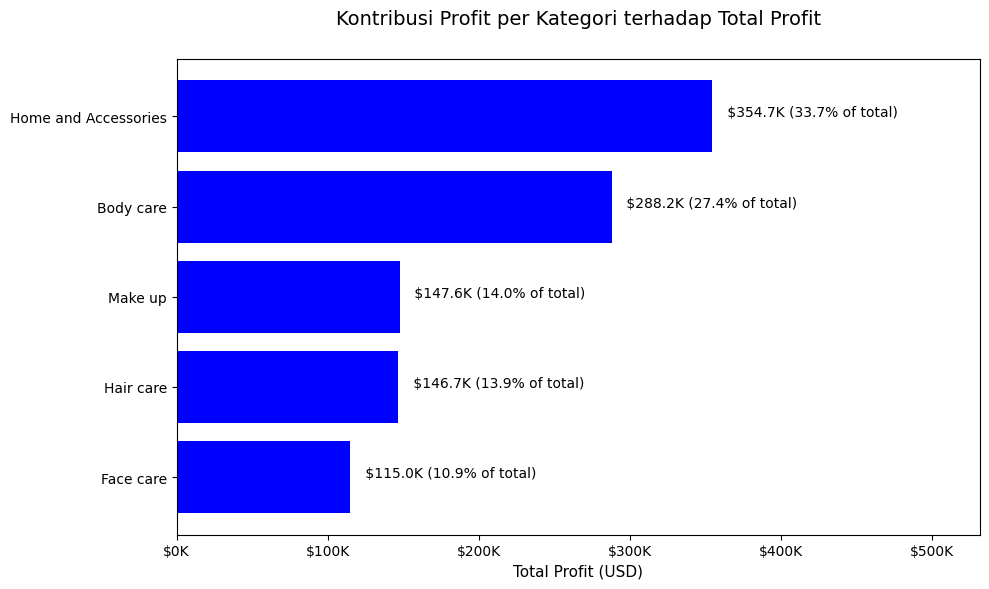

In [ ]:
# Agregasi profit per kategori
cat_perf = df.groupby('Category').agg(Total_Profit=('Profit', 'sum')).reset_index()

# Menghitung kontribusi profit kategori terhadap total profit
total_profit_all = cat_perf['Total_Profit'].sum()
cat_perf['Profit_Contribution_%'] = (cat_perf['Total_Profit'] / total_profit_all) * 100

# Mengurutkan dari profit tertinggi
cat_perf = cat_perf.sort_values('Total_Profit', ascending=True)

# ================= Visualisasi =================

# Menentukan ukuran canvas chart
plt.figure(figsize=(10, 6))

# Membuat horizontal bar chart untuk total profit per kategori
bars = plt.barh(
    cat_perf['Category'],
    cat_perf['Total_Profit'],
    color='blue')

# Format sumbu X ke $K
def format_usd_k(x, pos):
    return f'${int(x/1e3)}K'

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(format_usd_k))

# Menambahkan label nilai profit dan persentase kontribusi di ujung bar
offset = cat_perf['Total_Profit'].max() * 0.02  # jarak tambahan agar teks tidak menempel bar

for bar, contrib in zip(bars, cat_perf['Profit_Contribution_%']):
    width = bar.get_width()
    x_pos = max(width, 0) + offset # agar teks tetap di sisi kanan

    # Format teks label (nilai profit dalam $K + kontribusi %)
    label_text = f' ${width/1e3:.1f}K ({contrib:.1f}% of total)'
    text_color = 'black'

    plt.text(
        x_pos,
        bar.get_y() + bar.get_height()/2,
        label_text,
        fontsize=10,
        color=text_color)

# Memberi judul chart
plt.title('Kontribusi Profit per Kategori terhadap Total Profit', pad=25, fontsize=14)

# Memberi label pada sumbu x
plt.xlabel('Total Profit (USD)', fontsize=11)

# Skala sumbu x mulai dari 0
plt.xlim(0, cat_perf['Total_Profit'].max() * 1.5)

# Menampilkan chart
plt.tight_layout()
plt.show()

**Insight:**



*  Home and Accessories menjadi kategori utama berdasarkan profit yang dihasilkan dengan menyumbang $354.7K (33.7% dari total profit). Ini mencerminkan bahwa konsumen memiliki daya beli dan ketertarikan tinggi terhadap produk-produk dalam kategori ini

*  Posisi kedua ditempati oleh Body Care dengan $288.2K (27.4%). Dua kategori ini saja sudah menghasilkan lebih dari 61% total profit bisnis. Artinya, lebih dari separuh keberhasilan finansial perusahaan bertumpu pada dua kategori utama ini





Pertanyaannya kemudian adalah, apakah dominasi Home and Accessories di level kategori juga tercermin di level produk?

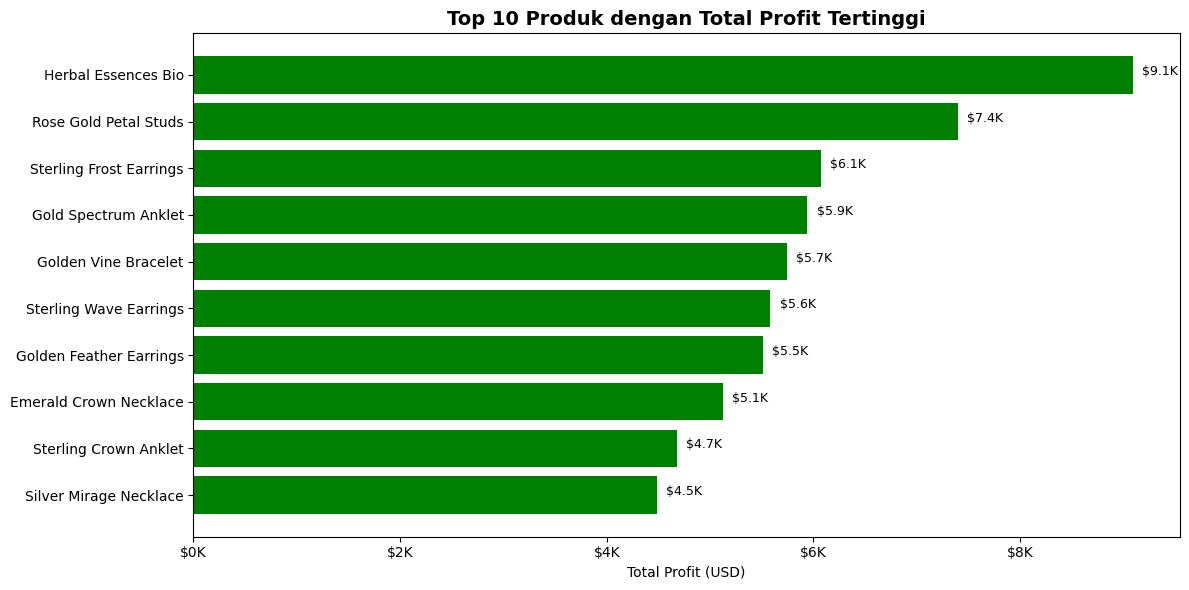

In [ ]:
# Menghitung total profit per produk
top10_products = (df.groupby('Product')['Profit'].sum().reset_index()
      .sort_values(by='Profit', ascending=True).tail(10))

# ==================== Visualisasi =========================

# Menetukan ukuran canvas chart
plt.figure(figsize=(12,6))

# Membuat horizontal bar chart untuk total profit per kategori
bars = plt.barh(
    top10_products['Product'],
    top10_products['Profit'],
    color='green')

# Menambahkan judul chart
plt.title('Top 10 Produk dengan Total Profit Tertinggi',
          fontsize=14, fontweight='bold')

# Menambahkan label pada sumbu x
plt.xlabel('Total Profit (USD)')

# Format sumbu X jadi K USD (dibagi 1000 saat ditampilkan)
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x/1000:.0f}K'))

#  Menambahkan Label di Ujung Bar
max_profit = top10_products['Profit'].max() # memberi jarak label dari ujung bar

for i, value in enumerate(top10_products['Profit']):
    plt.text(
        value + (max_profit * 0.01), # memberi jarak 1% dari profit maksimum agar teks tidak menempel ke bar
        i,
        f"${value/1000:.1f}K",
        fontsize=9)

# Menampilkan chart
plt.tight_layout()
plt.show()

**Insight:**



*  9 dari 10 produk merupakan produk aksesori. Ini memvalidasi secara langsung mengapa kategori Home and Accessories unggul di chart pertama. Profit yang tinggi tersebut bukan disebabkan karena adanya produk unggulan, melainkan karena kumpulan produk aksesori yang secara konsisten menghasilkan profit yang tinggi.

*   Namun, produk nomor 1 ternyata bukan dari aksesori. Herbal Essences Bio dari kategori Body Care memimpin dengan 9.1K, bahkan melampaui seluruh produk aksesori dengan gap yang cukup signifikan (~1.7K dari peringkat kedua).Ini menunjukkan bahwa kategori Body Care memiliki produk andalan yang sangat kuat.

*   Di sisi lain, Make Up, Hair Care, dan Face Care masing-masing hanya berkontribusi di kisaran 10-14%, dimana tidak satu pun produk dari ketiga kategori ini masuk ke dalam Top 10. Ini adalah indikasi kurangnya produk unggulan yang mampu mendorong profit secara signifikan di kategori-kategori tersebut.








Setelah mengetahui kategori dengan profit tertinggi, langkah selanjutnya adalah melihat dari sisi geografis untuk memahami dari mana profit tersebut paling banyak berasal.

Analisis berdasarkan negara membantu mengidentifikasi pasar paling menguntungkan yang layak diprioritaskan dalam strategi pemasaran, distribusi, dan ekspansi

### **Q2. Negara mana yang menghasilkan profit tertinggi?**

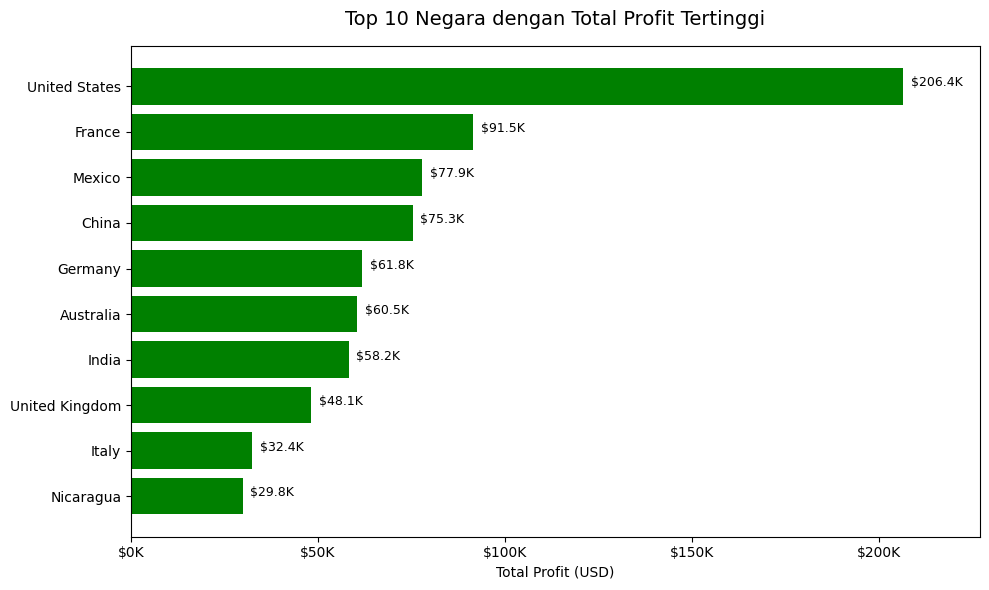

In [ ]:
# Agregasi total profit per Negara
country_profit = df.groupby('Country')['Profit'].sum().reset_index(name='Total_Profit')

# Ambil 10 negara dengan profit tertinggi, urut dari kecil ke besar
top10 = country_profit.sort_values('Total_Profit', ascending=True).tail(10)

# ========================= VISUALISASI =========================

# Menetukan ukuran canvas chart
fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal Bar Chart
ax.barh(
    y=top10['Country'],
    width=top10['Total_Profit'],
    color='green')

# memberi jarak label agar tidak menempel ke bar
max_profit = top10['Total_Profit'].max()

for i, (_, row) in enumerate(top10.iterrows()):
    label_text = f"${row['Total_Profit']/1e3:.1f}K"  # Membuat format label dalam satuan ribuan dolar (K USD)
    ax.text(
        x=row['Total_Profit'] + (max_profit * 0.01), # Posisi sedikit di kanan bar
        y=i, # Posisi vertikal mengikuti urutan bar
        s=label_text,
        fontsize=9,
        color='black')

# Format sumbu x menjadi format K $USD
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

# Menambahkan tambahan jarak di kanan agar label tidak terpotong
ax.set_xlim(0, max_profit * 1.1)

# Menambahkan judul chart
ax.set_title('Top 10 Negara dengan Total Profit Tertinggi', fontsize=14, pad=15)

# Menambahkan label pada sumbu x
ax.set_xlabel('Total Profit (USD)')

# Menampilkan chart
plt.tight_layout()
plt.show()

**Insight**:



*  **Amerika Serikat** menjadi kontributor profit terbesar dengan selisih yang cukup jauh dibanding negara lain. Selisihnya lebih dari dua kali lipat dibanding peringkat kedua. Ini menunjukkan bahwa sebagian besar kekuatan profit bisnis saat ini sangat bergantung pada performa pasar AS


*   **Prancis** dan **Meksiko** berada di posisi berikutnya dengan kontribusi yang cukup signifikan, meskipun masih jauh di bawah AS. Kehadiran Prancis mengindikasikan bahwa pasar Eropa memiliki daya beli dan minat yang stabil terhadap produk beauty. Sementara itu, Meksiko menunjukkan bahwa pasar Amerika Latin juga mampu memberikan kontribusi yang nyata dan tidak diabaikan dalam strategi pengembangan bisnis

*   **China** berada di posisi keempat dengan angka yang tidak berbeda jauh dengan Meksiko. Melihat ukuran pasar dan potensi industrinya, posisinya saat ini menunjukkan bahwa kontribusinya sudah cukup baik, tetapi masih terdapat peluang untuk peningkatan strategi bisnis


*   **Jerman**, **Australia**, dan **India** memiliki angka profit yang tidak terpaut jauh satu sama lain. Ketiganya menunjukkan pola yang stabil, namun belum menjadi kontributor utama. Pasar seperti ini biasanya memiliki potensi pertumbuhan jika diberikan perhatian lebih terarah, misalnya melalui promosi yang lebih spesifik atau penyesuaian produk.

*   Di posisi bawah Top 10 terdapat **Inggris**, **Italia**, dan **Nikaragua**. Yang menarik adalah Nikaragua tetap masuk daftar meskipun bukan termasuk pasar besar secara global. Ini menunjukkan bahwa meskipun skalanya lebih kecil, pasar tersebut tetap memberikan kontribusi yang konsisten terhadap profit





Perbedaan kontribusi antarnegara juga menandakan bahwa potensi pertumbuhan tidak hanya bergantung pada ekspansi geografis, tetapi juga pada pemahaman karakteristik pelanggan di masing-masing pasar.

Setelah melihat performa dari sisi negara, langkah selanjutnya adalah mengidentifikasi segmen pelanggan mana yang paling berkontribusi terhadap profit serta bagaimana respons mereka terhadap diskon. Analisis ini penting untuk memastikan strategi promosi untuk meningkatkan penjualan dan tetap menjaga profitabilitas

### **Q3. Segmen pelanggan mana yang paling menghasilkan profit tertinggi dan responsif terhadap diskon?**

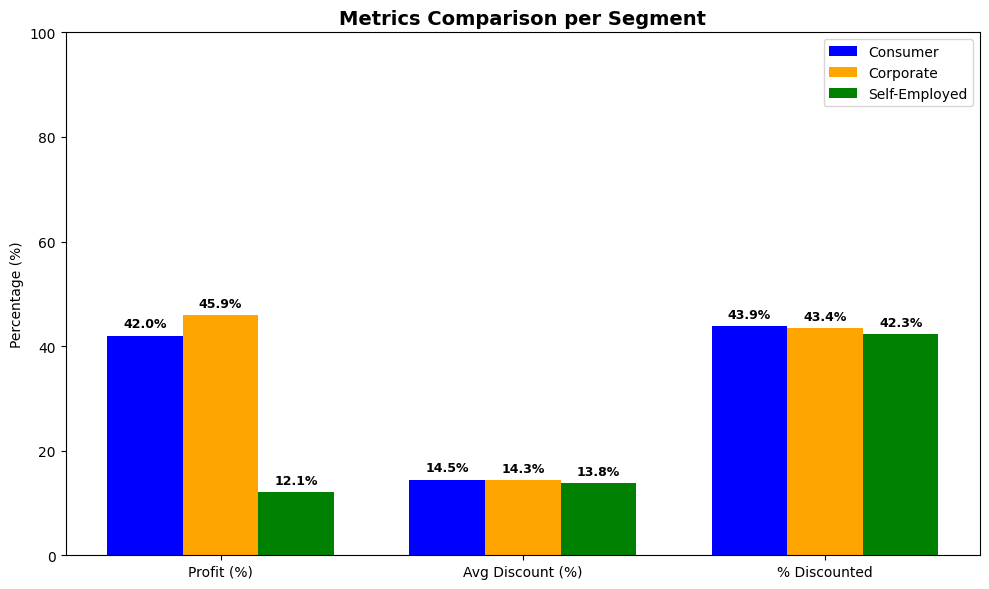

In [ ]:
# Agregasi data per Segment
seg_perf = df.groupby('Segment').agg(
    Total_Profit        = ('Profit', 'sum'),  # Total Profit per segment
    Avg_Discount        = ('Discount', 'mean'),  # Rata-rata diskon per segment (0–1)
    Pct_Discounted      = ('Discount', lambda x: (x > 0).sum() / len(x) * 100)  # % transaksi diskon
).reset_index()

# Ubah Total_Profit jadi persentase dari total profit seluruh segment
total_profit_all = seg_perf['Total_Profit'].sum()
seg_perf['Total_Profit_%'] = (seg_perf['Total_Profit'] / total_profit_all * 100).round(2)

# Menyiapkan data untuk grouped bar chart
metrics = ['Total_Profit_%', 'Avg_Discount', 'Pct_Discounted']
metric_labels = ['Profit (%)', 'Avg Discount (%)', '% Discounted'] # Label yang akan ditampilkan pada sumbu X
segments = seg_perf['Segment'].tolist() # Mengambil daftar nama segmen
n_segments = len(segments) # Menghitung jumlah segmen
n_metrics = len(metrics) # Menghitung jumlah metrik

x = np.arange(n_metrics) # Membuat array posisi dasar untuk sumbu X
width = 0.25 # Menentukan lebar bar dalam grup
colors = ['blue', 'orange', 'green'] # Menentukan warna


# ========================= Visualisasi =========================

# Menetukan ukuran canvas chart
fig, ax = plt.subplots(figsize=(10,6))

for i, segment in enumerate(segments):
    values = seg_perf.loc[seg_perf['Segment'] == segment, metrics].values.flatten()    # Ambil nilai tiap metric untuk tiap segment
    values[1] = values[1]*100 # Konversi Avg_Discount ke persen

    ax.bar(x + (i - 1)*width, values, width, color=colors[i], label=segment) # Plotting grouped bar chart per segment

# Menambahkan label di atas bar
for i, segment in enumerate(segments):
    values = seg_perf.loc[seg_perf['Segment'] == segment, metrics].values.flatten() # Mengambil nilai metrik untuk tiap segmen
    values[1] = values[1]*100  # Avg_Discount ke persen
    # Menambahkan teks di atas masing-masing bar
    for j, val in enumerate(values):
        ax.text(
            x[j] + (i - 1)*width, val + 1,
            f"{val:.1f}%", ha='center', va='bottom', fontsize=9)

# # Mengatur posisi dan label pada sumbu X
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)

# Setting sumbu Y
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, 100)

# Menambahkan judul chart
ax.set_title('Metrics Comparison per Segment', fontsize=14, fontweight='bold')

# Menampilkan legend
ax.legend()

# Menampilkan chart
plt.tight_layout()
plt.show()

**Insight:**



*   **Corporate** adalah segmen paling menguntungkan dan juga paling "royal" soal
diskon. Profit di segmen ini mencapai 45.9%, tertinggi di antara semua segmen. Namun, rata-rata nilai diskon mereka (14.3%) hampir sama dengan Consumer (14.5%). Artinya, profit tinggi ini bukan karena diskon, tapi karena volume atau value transaksi mereka memang lebih besar. Segmen ini harus dijaga loyalitasnya.

*  **Consumer** adalah segmen terbesar yang memanfaatkan diskon (43.9%), tapi profitnya kalah dari Corporate. Hampir 44% transaksi Consumer mendapatkan diskon, tapi profit-nya hanya 42%. Ada indikasi bahwa diskon yang diberikan ke Consumer kurang efisien. Banyak diskon yang digunakan, tapi return profitnya tidak seimbang dengan diskon yang diberikan. Perlu dikaji ulang strategi diskon di segmen ini.


*  **Self-Employed** perlu dianalisis lebih lanjut karena profit mereka hanya 12.1%, jauh tertinggal dari dua segmen lainnya. Padahal nilai diskon rata-rata mereka (13.8%) tidak terlalu berbeda. Ini mengindikasikan bahwa Self-Employed mungkin memiliki transaksi bernilai kecil, frekuensi rendah, atau produk yang dibeli marginnya memang tipis. Perlu evaluasi apakah segmen ini worth untuk dikejar lebih dalam, atau cukup dipertahankan sebagai segmen pelengkap.



*   Distribusi % Discounted ketiga segmen hampir merata (42-44%), yang berarti tidak ada segmen yang diperlakukan sangat berbeda soal kebijakan diskon. Terdapat peluang diferensiasi strategi diskon per segmen untuk mendorong keanikan profit, terutama di Self-Employed dan Consumer

Setelah memahami perbedaan profit dan respons diskon di tiap segmen, langkah berikutnya adalah melihat bagaimana performa bisnis secara keseluruhan berkembang dari tahun ke tahun. Analisis tren sales dan profit 2020-2023 akan membantu melihat apakah strategi yang diterapkan sudah mendorong pertumbuhan yang konsisten atau masih terdapat fluktuasi yang perlu diantisipasi

### **Q4. Bagaimana tren Sales dan keuntungan Profit dari tahun ke tahun (2020-2023)?**

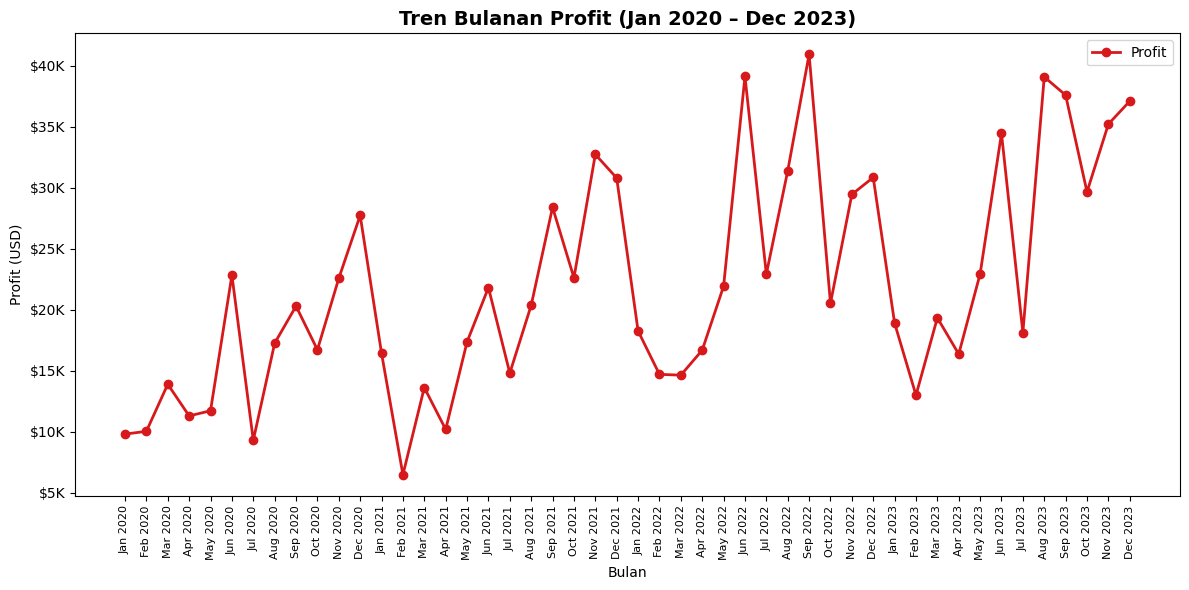

In [ ]:
# Aggregasi profit per bulan
monthly_profit = df.groupby('YearMonth').agg(Total_Profit=('Profit', 'sum')).reset_index()

# Mengubah formar YYYY-MM menjadi string time
monthly_profit['MonthYear_label'] = monthly_profit['YearMonth'].dt.strftime('%b %Y')

# ========================= Visualisasi Line Chart =========================

# Menentukan ukuran canvas chart
plt.figure(figsize=(12,6))

# Line chart Profit
plt.plot(
    monthly_profit['MonthYear_label'],       # X-axis: label bulan + tahun
    monthly_profit['Total_Profit'],          # Y-axis: profit
    color='#D7191C',                         # merah
    linewidth=2,
    marker='o',                              # marker bulat di tiap titik
    label='Profit')

# Setting X axis
plt.xticks(rotation=90, fontsize=8)          # Semua bulan ditampilkan, teks diputar 90°

# Setting Y-axis
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))  # format $K

# Menambahkan judul chart
plt.title('Tren Bulanan Profit (Jan 2020 – Dec 2023)', fontsize=14, fontweight='bold')

# Menambahkan label pada sumbu X dan Y
plt.xlabel('Bulan')
plt.ylabel('Profit (USD)')

# Menampilkan legend
plt.legend()

# Menampilkan chart
plt.tight_layout()
plt.show()

## Insight Tren Profit 2020-2023

• **Tren jangka panjang naik signifikan**:
Profit tumbuh dari sekitar 10K di awal 2020 menjadi stabil di kisaran 35-37K pada akhir 2023. Kenaikannya hampir 3-4 kali lipat, dengan pola yang semakin stabil setiap tahun.

• **Q1 selalu jadi periode terlemah**:
Januari-Februari konsisten mencatat profit terendah tiap tahun. Titik paling ekstrem terjadi di awal 2021 saat turun hingga 6K. Ini menunjukkan pola seasonal yang kuat di awal tahun.

• **Mei-Juni adalah fase pemulihan**:
Setelah lemah di Q1, profit hampir selalu naik signifikan di Q2. Lonjakan paling terlihat terjadi pada Juni 2022 yang mencapai 39K.

• **Q3 adalah periode puncak**:
September berulang kali menjadi bulan terkuat, dengan rekor tertinggi sepanjang periode terjadi di September 2022 sebesar 41K. Hal ini menunjukkan bahwa Q3 merupakan periode paling optimal dalam menghasilkan profit.

• **Akhir tahun tetap menunjukkan performa yang kuat**:
November dan Desember secara konsisten memberikan kontribusi profit yang baik. Meskipun terkadang ada fluktuasi sebelumnya, kuartal keempat cenderung ditutup dengan hasil yang positif.

• **Fluktuasi profit semakin terkendali**:
Pada periode 2020-2021, pergerakan profit terlihat cukup tajam dan tidak stabil. Namun, pada 2023 pola pergerakannya lebih stabil dan tidak terlalu ekstrem, yang menunjukkan bisnis semakin konsisten.

• **Titik terendah profit meningkat setiap tahun**:
Nilai profit terendah di tiap tahun cenderung lebih tinggi dibanding tahun sebelumnya. Ini menandakan bahwa meskipun ada pola penurunan musiman, secara keseluruhan profit bisnis semakin menguat dari waktu ke waktu.

Setelah melihat tren profit secara keseluruhan, analisis berikutnya berfokus pada sisi operasional, yaitu pola quantity pada setiap kategori produk. Statistik deskriptif seperti mean, median, dan modus akan membantu memahami karakter pembelian dan distribusi penjualan di tiap kategori.

## Statistik Deskriptif

### **Q5. Berapa Mean, median, Modus dari Quantity pada setiap kategori produk?**

=== Statistik Quantity per Kategori ===
               Category  Mean  Median  Mode
0             Body care  5.49     4.0     2
1             Face care  5.37     3.5     2
2             Hair care  5.38     3.5     2
3  Home and Accessories  5.35     3.0     2
4               Make up  5.38     4.0     2


/tmp/ipython-input-167/284334646.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Quantity', data=df, palette='Set2')


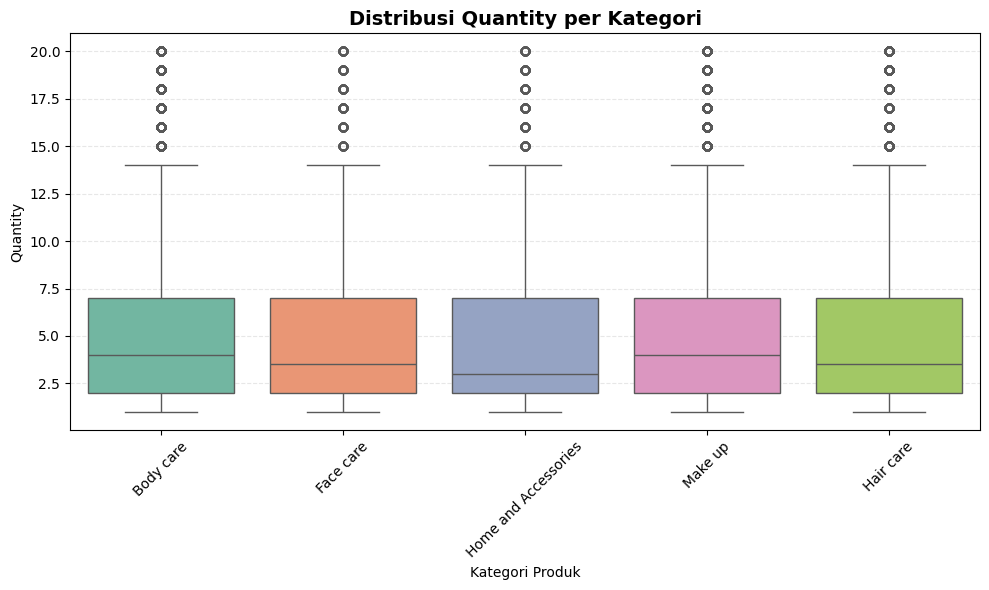

In [ ]:
# Menghitung mean & median per kategori
qty_stats = df.groupby('Category')['Quantity'].agg(
    Mean='mean',
    Median='median',
    Mode   = lambda x: x.mode()[0] if not x.mode().empty else np.nan # Mengambil nilai modus pertama
).reset_index()

# Menampilkan tabel ringkasan statistik
print("=== Statistik Quantity per Kategori ===")
print(qty_stats.round(2))

# ========================= Visualisasi Boxplot Quantity per Kategori =========================

# Menentukan ukuran canvas chart
plt.figure(figsize=(10,6))

# Plotting boxplot
sns.boxplot(x='Category', y='Quantity', data=df, palette='Set2')

# Menambahkan judul chart
plt.title('Distribusi Quantity per Kategori', fontsize=14, fontweight='bold')

# Menambahkan label sumbu X dan Y
plt.xlabel('Kategori Produk')
plt.ylabel('Quantity')

# Membuat label kategori pada sumbu X agar tidak menumpuk
plt.xticks(rotation=45)

# Menampilkan chart
plt.tight_layout()
plt.show()


**Insight:**

1. **Rata-rata Quantity per Transaksi Relatif Sama (Mean 5.35-5.49)**: Semua kategori berada di rentang rata-rata yang sangat berdekatan. Artinya, secara umum pelanggan membeli jumlah produk yang hampir sama, baik itu Body care, Face care, Hair care, Home & Accessories, maupun Make up. Tidak ada kategori yang secara ekstrem dibeli jauh lebih banyak dibanding yang lain.

2. **Median Tertinggi Ada di Body Care dan Make Up (4 Unit)**: Lebih dari setengah transaksi di dua kategori ini berisi minimal 4 unit. Ini menunjukkan pembelian cenderung lebih konsisten dalam jumlah yang agak banyak. Dibanding kategori lain, dua kategori ini terlihat paling disukai untuk dibeli dalam kuantitas lebih tinggi.

3. **Home & Accessories Quantity Paling Rendah Dibeli (Median 3 Unit)**: Setengah transaksi berada di 3 unit atau kurang. Ini menunjukkan bahwa produk di kategori ini cenderung tidak dibeli dalam jumlah besar per transaksi.

4. **Modus = 2 Unit di Semua Kategori**: Pembelian paling sering terjadi adalah 2 unit sekaligus dan pola ini sangat konsisten di seluruh kategori. Artinya kebiasaan belanja pelanggan cenderung membeli lebih dari satu, tetapi tidak langsung dalam jumlah besar.

5. **Outlier di Kisaran 15-20 Unit**: Semua kategori memiliki transaksi dengan jumlah sangat tinggi dan jauh di atas rata-rata dan median. Transaksi seperti ini berpotensi memberi kontribusi revenue yang signifikan.


Setelah memahami pola jumlah pembelian, pertanyaan berikutnya adalah apakah faktor lain seperti besaran diskon memiliki pengaruh signifikan terhadap profit yang dihasilkan.

Oleh karena itu, dilakukan analisis statistik inferensial untuk menguji hubungan antara diskon dan profit

## Statistik Inferensial

### **Q6. Apakah terdapat pengaruh yang signifikan antara besaran diskon terhadap Profit yang dihasilkan?**

Metode Uji Korelasi : Uji Spearman

α : 0,05

**H0**: Tidak ada hubungan antara diskon dan profit

**H1**: Ada hubungan antara diskon dan profit

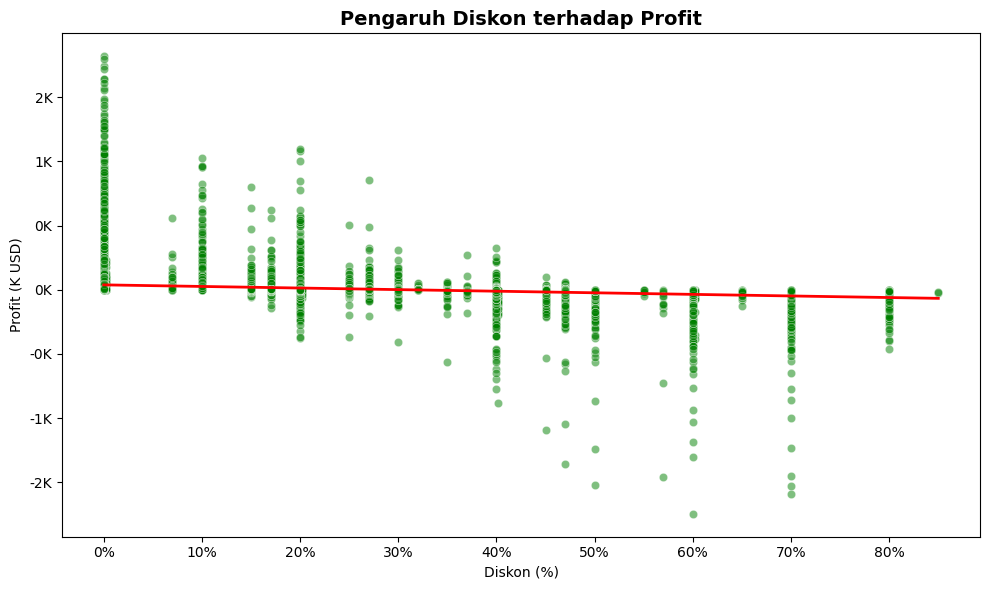

=== Uji Korelasi Spearman ===
Spearman rho : -0.623
P-value      : 0.00000
Kesimpulan: H0 ditolak → Terdapat hubungan yang signifikan antara Diskon dan Profit


In [ ]:
# Spearman correlation
rho, p_value = spearmanr(df['Discount'], df['Profit'])

# =========================
# Scatter plot dengan garis tren Spearman
# =========================
plt.figure(figsize=(10,6))

# Plot titik data
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.5, color='green')

# Plot garis regresi linier sebagai visualisasi tren
sns.regplot(x='Discount', y='Profit', data=df, scatter=False,
            color='red', line_kws={'linewidth':2})

# Memberikan judul chart
plt.title('Pengaruh Diskon terhadap Profit', fontsize=14, fontweight='bold')

# Memberikan label pada sumbu X dan Y
plt.xlabel('Diskon (%)')
plt.ylabel('Profit (K USD)')

# Setting label nilai sumbu X (format persen)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(0.1)) # Mengatur skala nilai yang dimunculkan tiap 10%
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*100:.0f}%'))

# Setting label nilai sumbu Y (format K USD)
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, pos: f'{y/1000:.0f}K'))


# Menampilkan chart
plt.tight_layout()
plt.show()

# =========================
# Interpretasi hasil
# =========================
print("=== Uji Korelasi Spearman ===")
print(f"Spearman rho : {rho:.3f}")
print(f"P-value      : {p_value:.5f}")

if p_value < 0.05:
    print("Kesimpulan: H0 ditolak → Terdapat hubungan yang signifikan antara Diskon dan Profit")
else:
    print("Kesimpulan: H0 gagal ditolak → Tidak terdapat hubungan yang signifikan antara Diskon dan Profit")

**Insight:**

* **Hubungan Diskon dan Profit Bersifat Negatif**:
Semakin besar diskon yang diberikan, semakin turun profit yang dihasilkan. Korelasi Spearman -0.623 dengan p-value mendekati nol menunjukkan hubungan yang cukup kuat. Artinya, diskon berdampak langsung pada penurunan profit

* **Transaksi Tanpa Diskon Paling Menguntungkan**:
Pada 0% diskon menghasilkan profit paling tinggi dan konsisten positif. Kondisi ini menunjukkan bahwa margin tetap terjaga ketika tidak ada potongan harga

* **Diskon Rendah Masih Relatif Aman**
Pada rentang 0-20%, profit umumnya masih positif meskipun mulai mengalami penurunan. Namun, ketika diskon melebihi 20%, mulai muncul transaksi dengan profit negatif

* **Diskon Tinggi Berisiko Menimbulkan Kerugian**
Pada tingkat diskon 40-60%, jumlah transaksi yang merugi semakin banyak dan nilai kerugiannya cukup besar. Di atas 60 persen, sebagian besar transaksi hampir tidak menghasilkan profit dan menghasilkan kerugian


## **E. Kesimpulan**


*   **Ketergantungan pada dua kategori utama:** Profit masih didominasi oleh Home & Accessories dan Body Care. Kategori oni perlu dijaga dengan memastikan ketersediaan produk unggulan dan strategi bundling untuk mendorong repeat order. Di sisi lain, kategori lain perlu dikembangkan melalui inovasi produk agar struktur profit tidak terlalu terpusat

*   **Konsentrasi profit pada satu negara utama:** Kontribusi profit masih terkonsentrasi di satu negara. Negara lain yang sudah cukup stabil bisa lebih dikembangkan lewat promosi atau penyesuaian produk agar kontribusinya meningkat dan bisnis tidak terlalu bergantung pada satu pasar.

*   **Perbedaan performa antar segmen pelanggan**: Corporate sudah terbukti paling menguntungkan dan tidak terlalu bergantung pada diskon, sehingga perlu menjaga loyalitas pada segmen ini. Untuk Consumer dan Self-Employed, diskon perlu lebih selektif karena terlalu banyak diskon justru tidak menaikkan profit secara seimbang

*   **Tren profit terus naik dan makin stabil:** Profit menunjukkan pertumbuhan yang konsisten dari tahun ke tahun. Periode Q3 dan akhir tahun bisa dimaksimalkan, sementara awal tahun yang cenderung lemah bisa diantisipasi dengan strategi penjualan yang lebih terencana

*   **Pola pembelian relatif stabil:** Mayoritas pembelian berada di jumlah sedang, sehingga strategi upselling dan bundling berpotensi meningkatkan rata-rata quantity per transaksi, terutama di kategori dengan median lebih rendah seperti Home & Accessories


*   **Dampak signifikan diskon terhadap profit:** Diskon ringan masih aman, tetapi diskon tinggi terbukti menurunkan profit. Karena itu, diskon sebaiknya dibatasi dan disesuaikan agar tetap menarik pelanggan tanpa mengurangi margin terlalu besar


Secara keseluruhan, bisnis sudah tumbuh dan cukup stabil, tetapi masih bergantung pada kategori, negara, dan segmen tertentu. Ke depan, fokusnya adalah menjaga yang sudah kuat, mengembangkan yang masih lemah, dan mengatur diskon dengan lebih bijak agar pertumbuhan tetap sehat dan tidak hanya mengejar penjualan, tetapi juga profit.


